# Caso 1: Detección de Facciones y Evolución Dinámica de Lealtades

## Planteamiento

El 23 de febrero de 1981, el teniente coronel Tejero irrumpió en el Congreso de los Diputados dando inicio a un golpe de estado que duró toda la noche. La hipótesis central de este caso es que **la lealtad militar no fue estática**: a medida que avanzaban las horas y los apoyos al golpe se desmoronaban, el discurso de los actores implicados fue cambiando.

El objetivo es rastrear empíricamente ese cambio mediante **clustering semántico dinámico** aplicado en tres ventanas temporales:

1. **Fase de confusión** (18:23h – 21:00h): el golpe acaba de comenzar, máxima incertidumbre
2. **Fase de consolidación** (21:00h – 01:14h): los golpistas intentan afianzar posiciones
3. **Fase de repliegue** (tras 01:14h): el discurso del Rey derrumba el golpe

La pregunta clave es: **¿en qué momento exacto fracasó el golpe a nivel de comunicaciones?**

### 1. Carga del dataset y exploración inicial

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('dataset_23f.csv')

print(f"Total documentos: {len(df)}")
print(f"Columnas: {list(df.columns)}")
print(f"\nDistribución por categoría:")
print(df['categoria'].value_counts())
print(f"\nDocumentos con texto completo: {(df['texto_completo'].str.len() > 10).sum()}")
print(f"Longitud media del texto: {df['texto_completo'].str.len().mean():.0f} caracteres")

Total documentos: 167
Columnas: ['id', 'titulo', 'tipo', 'estado', 'n_paginas', 'modelo_ocr', 'resumen', 'palabras_clave', 'texto_completo', 'fecha_iso', 'año_doc', 'mes_doc', 'dia_doc', 'actores', 'categoria']

Distribución por categoría:
categoria
juicio_1982       71
noche_23f         47
contexto_1981     35
sin_clasificar     9
otro_1987          2
otro_1978          2
otro_1975          1
Name: count, dtype: int64

Documentos con texto completo: 167
Longitud media del texto: 11676 caracteres


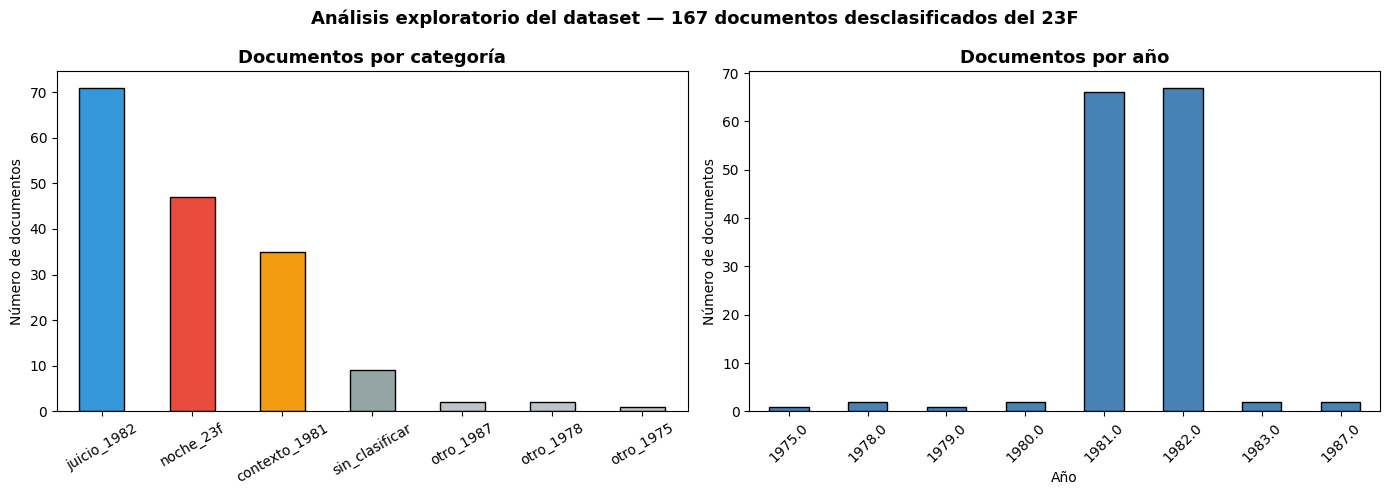

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cats = df['categoria'].value_counts()
colores_cat = {'noche_23f': '#e74c3c', 'contexto_1981': '#f39c12',
               'juicio_1982': '#3498db', 'sin_clasificar': '#95a5a6'}
colors = [colores_cat.get(c, '#bdc3c7') for c in cats.index]
cats.plot(kind='bar', ax=axes[0], color=colors, edgecolor='black')
axes[0].set_title('Documentos por categoría', fontsize=13, fontweight='bold')
axes[0].set_xlabel('')
axes[0].set_ylabel('Número de documentos')
axes[0].tick_params(axis='x', rotation=30)

df_año = df[df['año_doc'].notna()]
df_año['año_doc'].value_counts().sort_index().plot(
    kind='bar', ax=axes[1], color='steelblue', edgecolor='black')
axes[1].set_title('Documentos por año', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Año')
axes[1].set_ylabel('Número de documentos')
axes[1].tick_params(axis='x', rotation=45)

plt.suptitle('Análisis exploratorio del dataset — 167 documentos desclasificados del 23F',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 2. Filtrado de documentos para el análisis

Seleccionamos los 47 documentos de la categoría `noche_23f`, que recogen
comunicaciones, télex, informes del CESID y reacciones diplomáticas
producidos durante y en las 72 horas posteriores al golpe.

In [19]:
df_23f = df[df['categoria'] == 'noche_23f'].copy().reset_index(drop=True)

print(f"Documentos seleccionados: {len(df_23f)}")
print(f"\nTítulos:")
for _, row in df_23f.iterrows():
    print(f"  [{row['id']}] {row['titulo'][:85]}")

Documentos seleccionados: 47

Títulos:
  [1694] Transcripción de conversación telefónica de (presuntamente) García Carres y Tejero mi
  [1695] Transcripción de conversación telefónica de García Carres con otra persona después de
  [1696] Conversaciones telefónicas de (presuntamente) la unidad militar El Pardo (24 de febre
  [1697] "Documentación con una presunta planificación del golpe
  [1698] Documento manuscrito de posible planificación del golpe.
  [1699] Transcripción de cintas grabadas con conversaciones telefónicas con varias personas i
  [1700] Nota del EM de la Guardia Civil con una secuencia parcial de los hechos del asalto al
  [1701] Télex interiores y de agencias recibidos en 2ª sección EM el día 23-F informando del 
  [1720] SECRETO: oficio dando cuenta toma de declaración.
  [1722] RESERVADO: oficio dando cuenta toma de declaración.
  [1724] RESERVADO: oficio dando cuenta toma de declaración.
  [1740] RESERVADO: dación en cuenta de recurso de queja de Milans del Bosch so

### 3. Asignación de ventanas temporales

Dividimos los 47 documentos de `noche_23f` en tres fases históricas
basándonos en su contenido y contexto. Como la mayoría no tienen hora
exacta registrada, la asignación se basa en el tipo de documento
y el conocimiento histórico del 23F.

| Fase | Horario | Tipo de documentos |
|------|---------|-------------------|
| **Fase 1** | 18:23h – 21:00h | Planificación, comunicaciones internas del golpe |
| **Fase 2** | 21:00h – 01:14h | Operaciones militares, consolidación del golpe |
| **Fase 3** | Tras 01:14h | Respuesta institucional, reacción internacional |

In [20]:
FASE1_KW = [
    'planificación del golpe', 'garcia carres y tejero',
    'dentro del congreso', 'secuencia parcial de los hechos',
    'conversación telefónica de garcía carres',
    'esposa de tejero', 'asalto al congreso',
    'posible golpe de estado', 'involucionismo',
    'documentación con una presunta',
]

FASE3_KW = [
    'secretario haig', 'todman', 'reagan',
    'solidaridad con el pueblo español',
    'defensa de las instituciones democráticas',
    'intento de golpe de estado en españa',
    'intento de golpe contra la democracia',
    'intento de cambio violento', 'golpe fascista',
    'secuestro en el congreso', 'toma del parlamento',
    'relación cesid', 'prejujem',
    'actuación del departamento de defensa interna',
    'participación de miembros de la aome',
    'papel de la jujem', 'guión que sirvió de base',
    'nota al prejujem', 'relato de los sucesos',
    'informe de las distintas jefaturas',
    'situación actual en las distintas regiones',
    'actitud del cesid',
]

def asignar_ventana(row):
    todo = (str(row['titulo']) + ' ' + str(row['resumen'])).lower()
    if any(kw in todo for kw in FASE1_KW):
        return 'Fase 1\n(18:23-21:00h)\nConfusión'
    elif any(kw in todo for kw in FASE3_KW):
        return 'Fase 3\n(01:14h-amanecer)\nRepliegue'
    else:
        return 'Fase 2\n(21:00-01:14h)\nConsolidación'

df_23f['ventana'] = df_23f.apply(asignar_ventana, axis=1)

print("Distribución por ventana temporal:")
print(df_23f['ventana'].value_counts())
print()
for v in ['Fase 1\n(18:23-21:00h)\nConfusión',
          'Fase 2\n(21:00-01:14h)\nConsolidación',
          'Fase 3\n(01:14h-amanecer)\nRepliegue']:
    docs = df_23f[df_23f['ventana'] == v]
    print(f"\n{v.replace(chr(10),' ')} — {len(docs)} docs:")
    for _, r in docs.iterrows():
        print(f"  [{r['id']}] {r['titulo'][:75]}")

Distribución por ventana temporal:
ventana
Fase 3\n(01:14h-amanecer)\nRepliegue     26
Fase 2\n(21:00-01:14h)\nConsolidación    11
Fase 1\n(18:23-21:00h)\nConfusión        10
Name: count, dtype: int64


Fase 1 (18:23-21:00h) Confusión — 10 docs:
  [1694] Transcripción de conversación telefónica de (presuntamente) García Carres y
  [1695] Transcripción de conversación telefónica de García Carres con otra persona 
  [1697] "Documentación con una presunta planificación del golpe
  [1698] Documento manuscrito de posible planificación del golpe.
  [1699] Transcripción de cintas grabadas con conversaciones telefónicas con varias 
  [1700] Nota del EM de la Guardia Civil con una secuencia parcial de los hechos del
  [1788] "Nota ""Involucionismo político provocado por posible golpe militar"" (sin 
  [1789] "Nota ""Posible golpe de estado"" (sin firma)."
  [1794] Resumen de la actuación del Departamento de Defensa Interna.
  [1795] Actitud del CESID ante la situación provocada por los incident

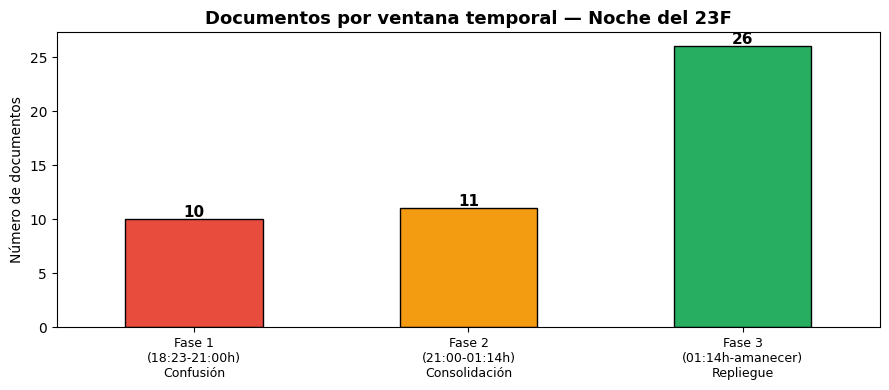

In [21]:
fig, ax = plt.subplots(figsize=(9, 4))
orden = ['Fase 1\n(18:23-21:00h)\nConfusión',
         'Fase 2\n(21:00-01:14h)\nConsolidación',
         'Fase 3\n(01:14h-amanecer)\nRepliegue']
colores = ['#e74c3c', '#f39c12', '#27ae60']
counts = df_23f['ventana'].value_counts().reindex(orden, fill_value=0)
counts.plot(kind='bar', ax=ax, color=colores, edgecolor='black')
ax.set_title('Documentos por ventana temporal — Noche del 23F',
             fontsize=13, fontweight='bold')
ax.set_ylabel('Número de documentos')
ax.set_xlabel('')
for i, v in enumerate(counts):
    ax.text(i, v + 0.2, str(v), ha='center', fontweight='bold', fontsize=11)
plt.xticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.show()

### 4. Generación de embeddings semánticos

Convertimos cada documento en un vector numérico de 384 dimensiones
usando el modelo `paraphrase-multilingual-MiniLM-L12-v2` de
`sentence-transformers`. Este modelo captura el significado semántico
del texto en español sin necesidad de API externa.

Usamos título + resumen como entrada, evitando el texto OCR completo
que puede contener ruido de digitalización.

In [22]:
from sentence_transformers import SentenceTransformer

print("Cargando modelo de embeddings...")
modelo = SentenceTransformer('paraphrase-multilingual-MiniLM-L12-v2')
print("Modelo cargado.")

def preparar_texto(row):
    titulo  = str(row['titulo'])  if pd.notna(row['titulo'])  else ''
    resumen = str(row['resumen'])[:600] if pd.notna(row['resumen']) else ''
    return f"{titulo}. {resumen}"

df_23f['texto_embedding'] = df_23f.apply(preparar_texto, axis=1)

print(f"\nGenerando embeddings para {len(df_23f)} documentos...")
embeddings = modelo.encode(
    df_23f['texto_embedding'].tolist(),
    show_progress_bar=True,
    batch_size=16
)
print(f"Shape embeddings: {embeddings.shape}")

Cargando modelo de embeddings...


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 7963.24it/s]
BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Modelo cargado.

Generando embeddings para 47 documentos...


Batches: 100%|██████████| 3/3 [00:01<00:00,  2.07it/s]

Shape embeddings: (47, 384)


### 5. Clustering semántico por ventana temporal

Aplicamos **K-Means con k=2** en cada ventana por separado.
Los dos clústeres representan dos tipos de discurso:
- **Clúster 0 — Autoritario/Golpista**: lenguaje operativo, de mando, conspirativo
- **Clúster 1 — Institucional/Constitucional**: lenguaje de control, respuesta, legitimidad

Reducimos a 2D con PCA para visualizar la separación semántica.

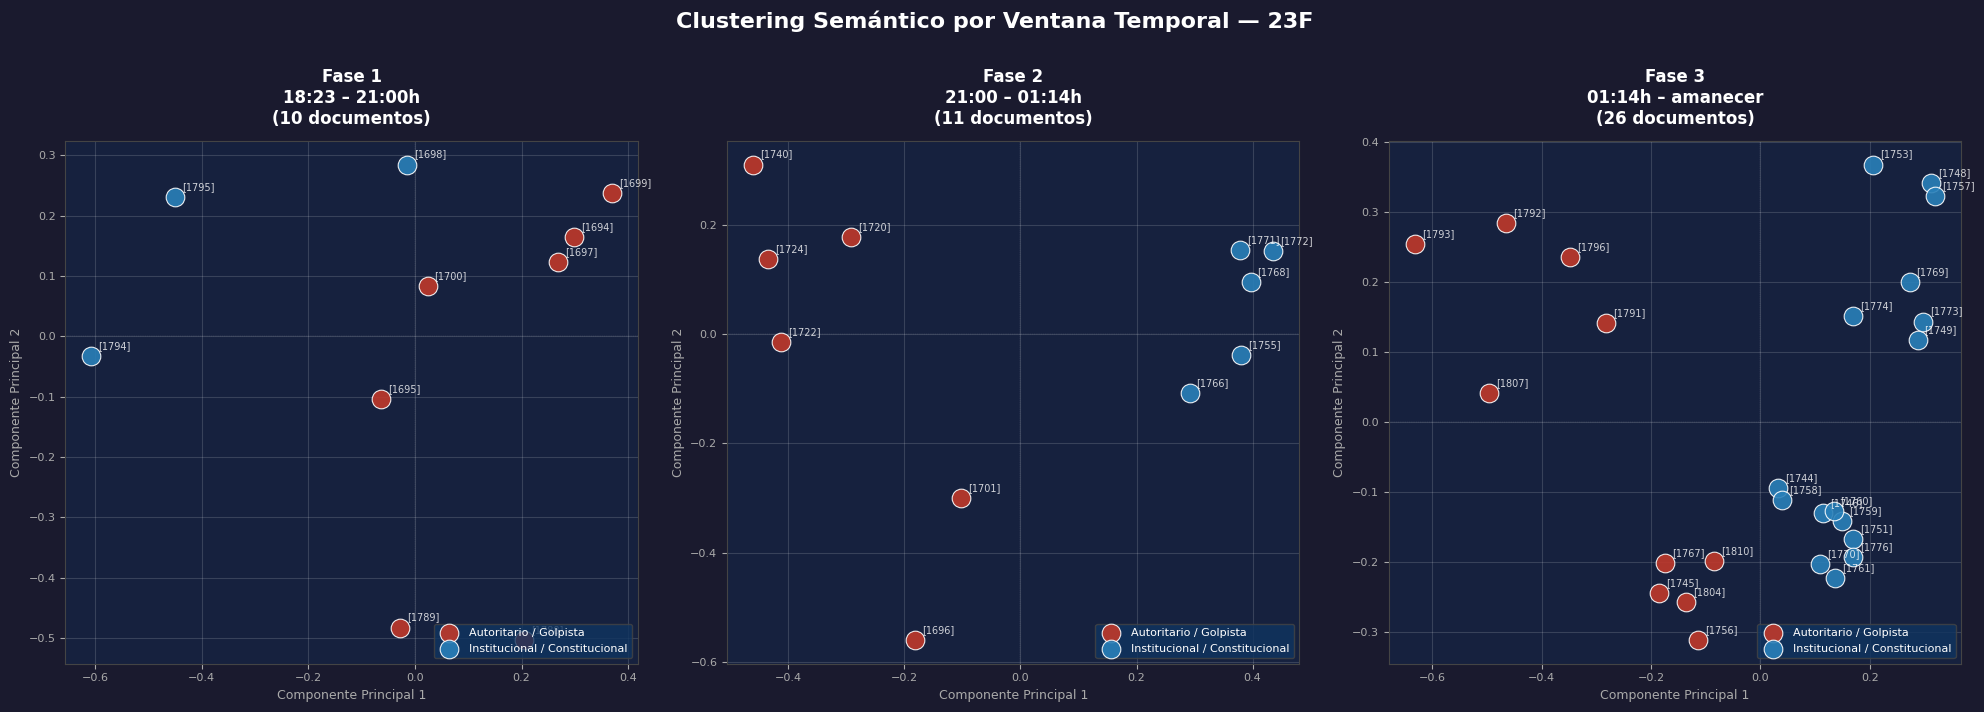

In [26]:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import normalize

embeddings_norm = normalize(embeddings)

ORDEN_FASES = [
    'Fase 1\n(18:23-21:00h)\nConfusión',
    'Fase 2\n(21:00-01:14h)\nConsolidación',
    'Fase 3\n(01:14h-amanecer)\nRepliegue'
]
TITULOS_FASES = ['Fase 1\n18:23 – 21:00h', 'Fase 2\n21:00 – 01:14h', 'Fase 3\n01:14h – amanecer']
COLORES_C = {0: '#c0392b', 1: '#2980b9'}
NOMBRES_C = {0: 'Autoritario / Golpista', 1: 'Institucional / Constitucional'}

fig, axes = plt.subplots(1, 3, figsize=(20, 7), facecolor='#1a1a2e')
fig.suptitle('Clustering Semántico por Ventana Temporal — 23F',
             fontsize=16, fontweight='bold', color='white', y=1.01)

resultados = {}

for idx, fase in enumerate(ORDEN_FASES):
    ax = axes[idx]
    ax.set_facecolor('#16213e')

    mask = df_23f['ventana'] == fase
    n = mask.sum()

    if n < 2:
        ax.set_title(f"Sin datos suficientes", color='white')
        ax.axis('off')
        continue

    emb_fase  = embeddings_norm[mask.values]
    docs_fase = df_23f[mask].reset_index(drop=True)
    k = min(2, n)

    kmeans   = KMeans(n_clusters=k, random_state=42, n_init=10)
    clusters = kmeans.fit_predict(emb_fase)
    df_23f.loc[mask, 'cluster'] = clusters
    resultados[fase] = {'docs': docs_fase, 'clusters': clusters}

    pca    = PCA(n_components=2, random_state=42)
    emb_2d = pca.fit_transform(emb_fase)

    for c in range(k):
        mc = clusters == c
        ax.scatter(emb_2d[mc, 0], emb_2d[mc, 1],
                   c=COLORES_C[c], label=NOMBRES_C[c],
                   s=180, alpha=0.9, edgecolors='white', linewidth=0.8, zorder=3)

    # Etiquetas solo con número de documento, más limpias
    for i in range(len(docs_fase)):
        ax.annotate(f"[{docs_fase.loc[i, 'id']}]",
                    (emb_2d[i, 0], emb_2d[i, 1]),
                    fontsize=7, color='white', alpha=0.8,
                    xytext=(5, 5), textcoords='offset points')

    # Líneas de separación entre clústeres (convex hull visual)
    ax.axhline(y=0, color='white', linewidth=0.3, alpha=0.2, linestyle='--')
    ax.axvline(x=0, color='white', linewidth=0.3, alpha=0.2, linestyle='--')

    ax.set_title(TITULOS_FASES[idx] + f'\n({n} documentos)',
                 fontsize=12, fontweight='bold', color='white', pad=12)
    ax.set_xlabel('Componente Principal 1', fontsize=9, color='#aaaaaa')
    ax.set_ylabel('Componente Principal 2', fontsize=9, color='#aaaaaa')
    ax.tick_params(colors='#aaaaaa', labelsize=8)
    for spine in ax.spines.values():
        spine.set_edgecolor('#444444')
    ax.grid(True, alpha=0.15, color='white')

    legend = ax.legend(fontsize=8, loc='lower right',
                       facecolor='#0f3460', edgecolor='#444444',
                       labelcolor='white', framealpha=0.8)

plt.tight_layout()
plt.show()

Los ejes PC1 y PC2 son componentes artificiales generados por PCA para 
reducir los 384 dimensiones del embedding a 2 dimensiones visualizables. 
No tienen un significado lingüístico directo: lo relevante es la distancia 
entre puntos — documentos cercanos comparten lenguaje similar, 
documentos alejados tienen discursos distintos.

### 6. Evolución del discurso a lo largo de la noche

Analizamos cómo cambia el peso de cada clúster entre las tres fases.
Una caída del discurso autoritario en la Fase 3 es evidencia empírica
del colapso comunicacional del golpe tras el discurso del Rey (01:14h).

                               fase  autoritario  institucional  n
    Fase 1 (18:23-21:00h) Confusión         70.0           30.0 10
Fase 2 (21:00-01:14h) Consolidación         54.5           45.5 11
 Fase 3 (01:14h-amanecer) Repliegue         38.5           61.5 26


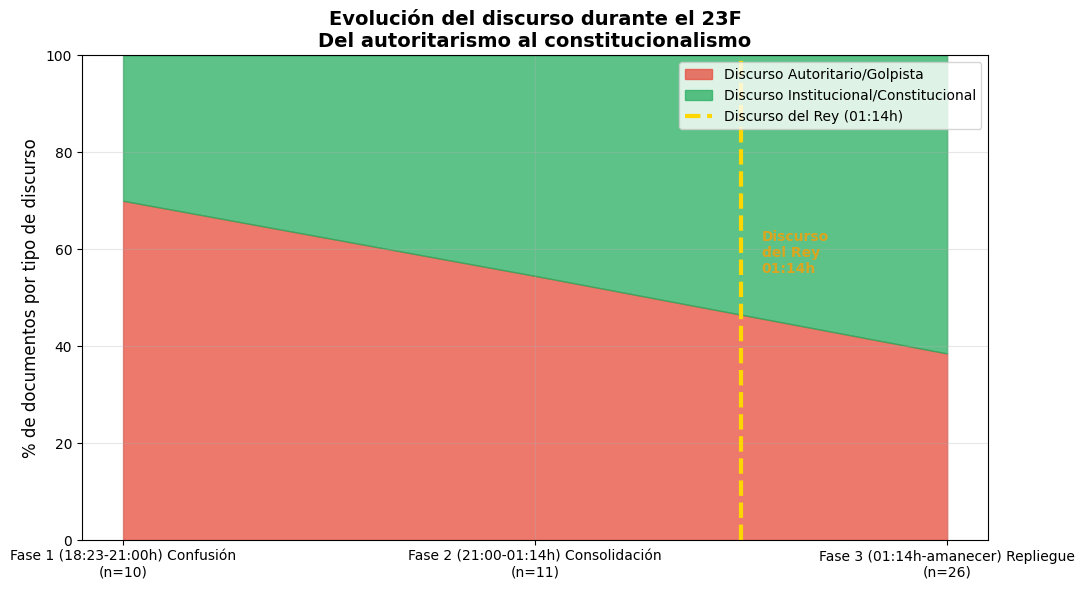

In [24]:
evolucion = []
for fase in ORDEN_FASES:
    docs = df_23f[df_23f['ventana'] == fase].copy()
    if len(docs) == 0 or 'cluster' not in docs.columns:
        continue
    docs = docs.dropna(subset=['cluster'])
    n_total = len(docs)
    if n_total == 0:
        continue
    n_aut  = (docs['cluster'] == 0).sum()
    n_inst = (docs['cluster'] == 1).sum()
    evolucion.append({
        'fase':          fase.replace('\n', ' '),
        'autoritario':   round(n_aut  / n_total * 100, 1),
        'institucional': round(n_inst / n_total * 100, 1),
        'n':             n_total
    })

df_evol = pd.DataFrame(evolucion)
print(df_evol.to_string(index=False))

fig, ax = plt.subplots(figsize=(11, 6))
x = range(len(df_evol))

ax.fill_between(x, df_evol['autoritario'],
                color='#e74c3c', alpha=0.75,
                label='Discurso Autoritario/Golpista')
ax.fill_between(x, df_evol['autoritario'], 100,
                color='#27ae60', alpha=0.75,
                label='Discurso Institucional/Constitucional')

if len(df_evol) > 1:
    ax.axvline(x=1.5, color='gold', linewidth=3,
               linestyle='--', label='Discurso del Rey (01:14h)')
    ax.text(1.55, 55, 'Discurso\ndel Rey\n01:14h',
            fontsize=10, color='goldenrod', fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(
    [f"{r['fase']}\n(n={r['n']})" for _, r in df_evol.iterrows()],
    fontsize=10)
ax.set_ylabel('% de documentos por tipo de discurso', fontsize=12)
ax.set_ylim(0, 100)
ax.set_title('Evolución del discurso durante el 23F\n'
             'Del autoritarismo al constitucionalismo',
             fontsize=14, fontweight='bold')
ax.legend(loc='upper right', fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 7. Análisis de trayectorias individuales

Rastreamos qué actores aparecen en múltiples ventanas temporales
y si cambian de clúster. Un actor que pasa del clúster autoritario
al institucional es una señal empírica del momento en que el golpe fracasó.

In [25]:
patron_actor = re.compile(
    r'(Coronel|General|Capitán|Teniente|Comandante|Almirante|'
    r'Gral\.|Tcol\.|Tejero|Milans|Armada|Cortina|Suárez|Gutiérrez)',
    re.IGNORECASE)

orden_num = {
    'Fase 1\n(18:23-21:00h)\nConfusión':    1,
    'Fase 2\n(21:00-01:14h)\nConsolidación':2,
    'Fase 3\n(01:14h-amanecer)\nRepliegue': 3
}

trayectorias = {}
for _, row in df_23f.iterrows():
    if pd.isna(row.get('cluster')):
        continue
    kws     = str(row['palabras_clave']).split('|')
    actores = [k.strip() for k in kws if patron_actor.search(k)]
    fase_n  = orden_num.get(row['ventana'], 2)
    cluster = int(row['cluster'])
    for actor in actores:
        if actor not in trayectorias:
            trayectorias[actor] = {}
        trayectorias[actor][fase_n] = cluster

multi = {k: v for k, v in trayectorias.items() if len(v) >= 2}

print(f"Actores con presencia en múltiples fases: {len(multi)}\n")
for actor, fases in sorted(multi.items()):
    traj = ' → '.join([
        f"F{f}:{'Autoritario' if c==0 else 'Institucional'}"
        for f, c in sorted(fases.items())
    ])
    cambio = '⚠️  CAMBIO' if len(set(fases.values())) > 1 else '✓ Estable'
    print(f"  {actor[:50]:<52} {traj}  {cambio}")

Actores con presencia en múltiples fases: 3

  Capitán General de Valencia                          F1:Autoritario → F3:Autoritario  ✓ Estable
  Dirección General de la Guardia Civil                F1:Institucional → F3:Autoritario  ⚠️  CAMBIO
  Tejero                                               F1:Autoritario → F3:Autoritario  ✓ Estable
